In [23]:
import pandas as pd
import joblib
import os
from google.colab import drive
drive.mount('/content/drive')
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de modelos
ruta_models = '/content/drive/MyDrive/modelos_smoking/'
xgboost = joblib.load(os.path.join(ruta_models, 'XGBOOST.pkl'))
gboost = joblib.load(os.path.join(ruta_models, 'gboosting.pkl'))
stack_modelo = joblib.load(os.path.join(ruta_models, 'stackingmod.pkl'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
from sklearn.model_selection import train_test_split

# 1. Cargamos el dataset procesado
df = pd.read_csv('/content/drive/My Drive/Training_And_Testing_Dataset/smoking_prediction_processed.csv')

# 2. Eliminamos las constantes (igual que en el entrenamiento)
cols_const = [c for c in df.columns if df[c].nunique() <= 1]
df = df.drop(columns=cols_const)

# 3. Definimos variables
X = df.drop(columns=['ID', 'smoking'])
y = df['smoking']

# 4. VOLVEMOS A HACER EL SPLIT (¡Importante!)
# Usamos el mismo random_state=42 para que el test sea exactamente el mismo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Datos de validación listos.")

✅ Datos de validación listos.


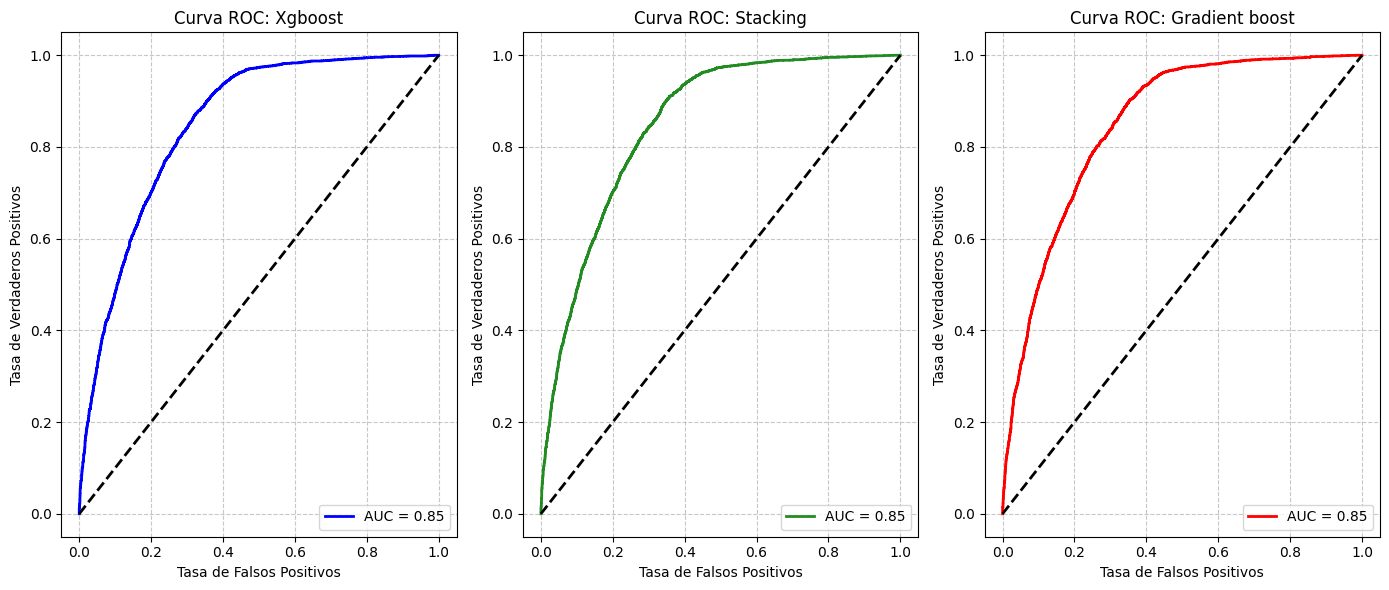

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

def plot_roc_en_eje(ax, y_true, y_prob, label, color_linea): # <--- Nuevo parámetro
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color_linea, lw=2, label=f'AUC = {roc_auc:.2f}') # Usamos el color aquí
    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_title(f'Curva ROC: {label}')
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.legend(loc="lower right")
    ax.grid(True, linestyle='--', alpha=0.7)

# Graficar xgboost (ejemplo: azul)
plot_roc_en_eje(axes[0], y_test, xgboost.predict_proba(X_test)[:,1], 'Xgboost', 'blue')

# Graficar gboosting (ejemplo: rojo)
plot_roc_en_eje(axes[2], y_test, gboost.predict_proba(X_test)[:,1], 'Gradient boost', 'red')

# Graficar Stacking (ejemplo: verde bosque para que destaque)
plot_roc_en_eje(axes[1], y_test, stack_modelo.predict_proba(X_test)[:,1], 'Stacking', 'forestgreen')

plt.tight_layout()
plt.show()

--- Reporte de Clasificación (Random Forest) ---
              precision    recall  f1-score     support
0              0.831195  0.787496  0.808756   6334.0000
1              0.663416  0.723677  0.692237   3666.0000
accuracy       0.764100  0.764100  0.764100      0.7641
macro avg      0.747305  0.755587  0.750497  10000.0000
weighted avg   0.769687  0.764100  0.766040  10000.0000


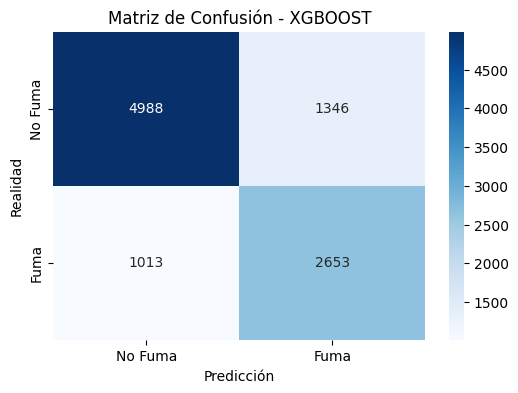

In [34]:
# ==========================================
# 05_validacion.ipynb - Resumen Estadístico
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generamos predicciones finales con tu mejor modelo (RF)
y_pred_rf = xgboost.predict(X_test)

# 2. Tabla de métricas (Precision, Recall, F1, Accuracy)
print("--- Reporte de Clasificación (Random Forest) ---")
report = classification_report(y_test, y_pred_rf, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)

# 3. Matriz de Confusión Visual
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fuma', 'Fuma'],
            yticklabels=['No Fuma', 'Fuma'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión - XGBOOST')
plt.show()

--- Reporte de Clasificación (Random Forest) ---
              precision    recall  f1-score     support
0              0.828520  0.792548  0.810135   6334.0000
1              0.666582  0.716585  0.690680   3666.0000
accuracy       0.764700  0.764700  0.764700      0.7647
macro avg      0.747551  0.754566  0.750407  10000.0000
weighted avg   0.769153  0.764700  0.766343  10000.0000


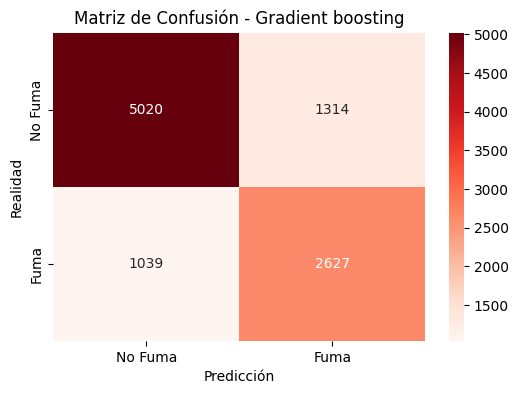

In [31]:
# ==========================================
# 05_validacion.ipynb - Resumen Estadístico
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generamos predicciones finales con tu mejor modelo (RF)
y_pred_rf = gboost.predict(X_test)

# 2. Tabla de métricas (Precision, Recall, F1, Accuracy)
print("--- Reporte de Clasificación (Random Forest) ---")
report = classification_report(y_test, y_pred_rf, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)

# 3. Matriz de Confusión Visual
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Fuma', 'Fuma'],
            yticklabels=['No Fuma', 'Fuma'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión - Gradient boosting')
plt.show()

--- Reporte de Clasificación (Stacking) ---
              precision    recall  f1-score     support
0              0.821238  0.802179  0.811597   6334.0000
1              0.671387  0.698309  0.684584   3666.0000
accuracy       0.764100  0.764100  0.764100      0.7641
macro avg      0.746313  0.750244  0.748090  10000.0000
weighted avg   0.766303  0.764100  0.765034  10000.0000


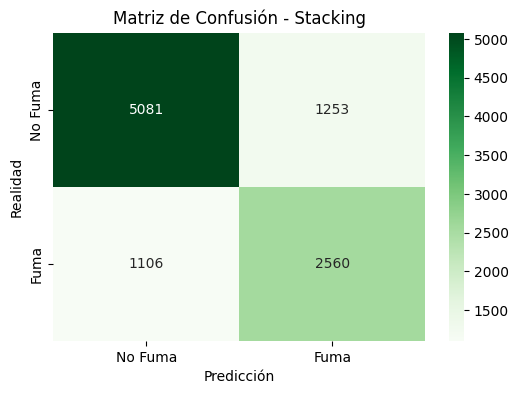

In [28]:
# ==========================================
# 05_validacion.ipynb - Resumen Stacking
# ==========================================

# 1. Generamos predicciones con el modelo de Stacking
y_pred_stack = stack_modelo.predict(X_test)

# 2. Reporte de Clasificación detallado
print("--- Reporte de Clasificación (Stacking) ---")
report_stack = classification_report(y_test, y_pred_stack, output_dict=True)
df_report_stack = pd.DataFrame(report_stack).transpose()
print(df_report_stack)

# 3. Matriz de Confusión Visual
plt.figure(figsize=(6, 4))
cm_stack = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Greens', # Usamos verde para diferenciarlo del azul del RF
            xticklabels=['No Fuma', 'Fuma'],
            yticklabels=['No Fuma', 'Fuma'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión - Stacking')
plt.show()

In [27]:
from sklearn.metrics import f1_score

# Asegúrate de que tus modelos y datos estén definidos:
# Modelos: xgboost, gboost, stack_modelo
# Datos: X_tr, X_te, y_tr, y_te (o los nombres que uses para tu split)

nombres = ['XGBoost', 'Gradient Boosting', 'Stacking Final']
modelos = [xgboost, gboost, stack_modelo]

print(f"{'Modelo':<20} | {'F1 Train':<10} | {'F1 Test':<10} | {'Brecha':<10}")
print("-" * 60)

for nombre, mod in zip(nombres, modelos):
    # Predicciones
    pred_tr = mod.predict(X_train)
    pred_te = mod.predict(X_test)

    # Cálculos
    f1_tr = f1_score(y_train, pred_tr)
    f1_te = f1_score(y_test, pred_te)
    brecha = f1_tr - f1_te

    print(f"{nombre:<20} | {f1_tr:.4f}     | {f1_te:.4f}     | {brecha:.4f}")

Modelo               | F1 Train   | F1 Test    | Brecha    
------------------------------------------------------------
XGBoost              | 0.7118     | 0.6922     | 0.0196
Gradient Boosting    | 0.7128     | 0.6907     | 0.0222
Stacking Final       | 0.7184     | 0.6846     | 0.0338


In [26]:
print(f"Tipo de objeto en 'xgboost': {type(xgboost)}")
print(f"Tipo de objeto en 'gboost': {type(gboost)}")
print(f"Tipo de objeto en 'stack_modelo': {type(stack_modelo)}")

Tipo de objeto en 'xgboost': <class 'xgboost.sklearn.XGBClassifier'>
Tipo de objeto en 'gboost': <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Tipo de objeto en 'stack_modelo': <class 'sklearn.ensemble._stacking.StackingClassifier'>


Se termina por elegir el XGBoost como modelo para generar la predicción ya que sus resultado en la matriz de confusión acusan que genera la menor cantidad de falsos negativos,

Tambien, presenta una diferencia menor entre el f1 score de train y test, por lo que es mejor generalizando, al contrario que el modelo de stacking, que a pesar de que presenta capacidad de aprendizaje no es tan confiable.